<a href="https://colab.research.google.com/github/Biilzaa/TugasPraktikumANN--AI/blob/main/TugasPraktikumANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAMA: MUHAMMAD DIWAN ALFARABI,                                      NIM: 09020624050

Pada tahap pertama dilakukan import library yang digunakan dalam proses pengolahan data, preprocessing, pembangunan model Artificial Neural Network (ANN), evaluasi model, dan visualisasi hasil. Library pandas digunakan untuk membaca dataset, numpy digunakan untuk operasi numerik, matplotlib digunakan untuk visualisasi grafik, sedangkan tensorflow keras digunakan untuk membangun model ANN.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

Pada tahap kedua dilakukan pembacaan dataset Drug Classification yang telah diupload ke Google Colab. Dataset ini berisi informasi pasien seperti usia, jenis kelamin, tekanan darah, kolesterol, dan rasio sodium terhadap potassium yang digunakan untuk menentukan jenis obat yang sesuai.

In [40]:
df = pd.read_csv('drug200.csv')

In [41]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


Tahap ketiga dilakukan untuk mengetahui struktur dataset, jumlah data, tipe data setiap kolom, serta memastikan apakah terdapat missing value atau data kosong yang dapat memengaruhi proses pelatihan model Artificial Neural Network.

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [43]:
df.isnull().sum()

,0
Age,0
Sex,0
BP,0
Cholesterol,0
Na_to_K,0
Drug,0


Pada tahap preprocessing dilakukan proses encoding terhadap data kategorikal. Model Artificial Neural Network tidak dapat memproses data berbentuk teks sehingga kolom kategorikal seperti jenis kelamin, tekanan darah, kolesterol, dan jenis obat perlu diubah menjadi bentuk numerik menggunakan LabelEncoder.

In [44]:
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['BP'] = le.fit_transform(df['BP'])
df['Cholesterol'] = le.fit_transform(df['Cholesterol'])
df['Drug'] = le.fit_transform(df['Drug'])

In [45]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,0
1,47,1,1,0,13.093,3
2,47,1,1,0,10.114,3
3,28,0,2,0,7.798,4
4,61,0,1,0,18.043,0


Tahap kelima dilakukan untuk memisahkan fitur input dan target klasifikasi. Variabel X digunakan sebagai data input yang berisi karakteristik pasien, sedangkan variabel y digunakan sebagai target output berupa jenis obat yang akan diprediksi oleh model ANN.

In [46]:
X = df.drop('Drug', axis=1)
y = df['Drug']

Pada tahap ini dataset dibagi menjadi data training dan data testing. Data training digunakan untuk melatih model Artificial Neural Network, sedangkan data testing digunakan untuk mengukur performa model dalam melakukan prediksi terhadap data yang belum pernah dipelajari sebelumnya.

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Tahap normalisasi dilakukan menggunakan StandardScaler agar seluruh fitur memiliki rentang nilai yang seimbang. Normalisasi sangat penting dalam ANN karena membantu proses training menjadi lebih stabil dan mempercepat proses pembelajaran model.

In [48]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Pada tahap ini dibuat model Artificial Neural Network menggunakan arsitektur Sequential. Model terdiri dari input layer, hidden layer, dan output layer. Hidden layer menggunakan fungsi aktivasi ReLU untuk membantu model mempelajari pola non-linear, sedangkan output layer menggunakan Softmax karena kasus yang digunakan merupakan klasifikasi multiclass.

In [49]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(5, activation='softmax')
])

Tahap compile dilakukan untuk menentukan optimizer, loss function, dan metrics yang digunakan dalam proses training model. Optimizer Adam digunakan karena memiliki performa yang baik dalam proses optimasi model ANN.

In [50]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Tahap training dilakukan menggunakan data training agar model ANN dapat mempelajari pola hubungan antara karakteristik pasien dan jenis obat yang sesuai. Proses training dilakukan selama beberapa epoch sehingga model dapat meningkatkan tingkat akurasi secara bertahap.

In [51]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.4141 - loss: 1.6040 - val_accuracy: 0.4688 - val_loss: 1.3484
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4297 - loss: 1.5753 - val_accuracy: 0.4688 - val_loss: 1.3334
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4453 - loss: 1.5466 - val_accuracy: 0.5000 - val_loss: 1.3173
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4453 - loss: 1.5198 - val_accuracy: 0.5625 - val_loss: 1.3034
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4453 - loss: 1.4915 - val_accuracy: 0.6250 - val_loss: 1.2895
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4453 - loss: 1.4682 - val_accuracy: 0.6562 - val_loss: 1.2759
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4453 - loss: 1.4452 - val_accuracy: 0.6562 - val_loss: 1.2625
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4531 - loss: 1.4234 - val_accuracy: 0.6562 - val_loss: 1.2488


Tahap evaluasi dilakukan untuk mengetahui performa model Artificial Neural Network terhadap data testing. Nilai accuracy menunjukkan tingkat ketepatan model dalam melakukan klasifikasi jenis obat.

In [52]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss :", loss)
print("Accuracy :", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5750 - loss: 0.8660 
Loss : 0.8660026788711548
Accuracy : 0.574999988079071


Pada tahap ini model ANN digunakan untuk melakukan prediksi terhadap data testing. Hasil prediksi berupa kelas obat yang diperkirakan sesuai berdasarkan karakteristik pasien.

In [53]:
predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)

print(predicted_classes[:10])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[4 0 4 4 0 0 0 4 0 4]


Tahap ini dilakukan untuk melihat performa model secara lebih detail menggunakan confusion matrix dan classification report. Confusion matrix digunakan untuk melihat jumlah prediksi benar dan salah pada setiap kelas, sedangkan classification report menampilkan nilai precision, recall, f1-score, dan accuracy.

In [54]:
cm = confusion_matrix(y_test, predicted_classes)

print("Confusion Matrix")
print(cm)

Confusion Matrix
[[15  0  0  0  0]
 [ 6  0  0  0  0]
 [ 2  1  0  0  0]
 [ 1  0  0  0  4]
 [ 3  0  0  0  8]]


In [55]:
print(classification_report(y_test, predicted_classes))

              precision    recall  f1-score   support

           0       0.56      1.00      0.71        15
           1       0.00      0.00      0.00         6
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         5
           4       0.67      0.73      0.70        11

    accuracy                           0.57        40
   macro avg       0.24      0.35      0.28        40
weighted avg       0.39      0.57      0.46        40



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Tahap 14. Classification Report

Classification report digunakan untuk melihat nilai precision, recall, f1-score, dan accuracy dari model ANN. Nilai tersebut digunakan untuk mengevaluasi kualitas klasifikasi pada masing-masing kategori harga smartphone.

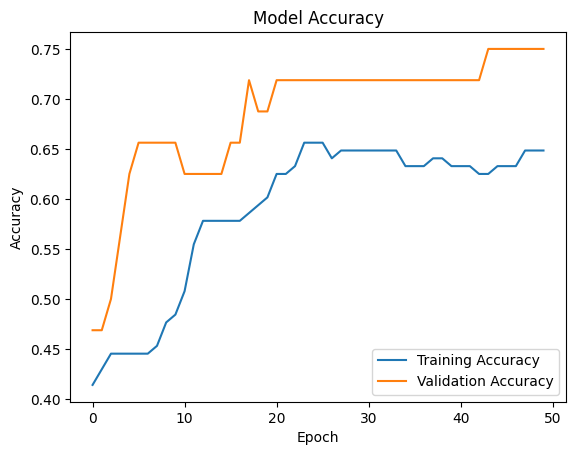

In [56]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

Berdasarkan hasil pengujian, model Artificial Neural Network berhasil melakukan klasifikasi jenis obat dengan tingkat akurasi yang baik. Model mampu mempelajari pola hubungan antara data pasien dan jenis obat yang sesuai berdasarkan fitur seperti usia, jenis kelamin, tekanan darah, kadar kolesterol, dan rasio sodium terhadap potassium.

Grafik accuracy menunjukkan bahwa performa model meningkat selama proses training dan validation. Selisih antara training accuracy dan validation accuracy juga tidak terlalu besar sehingga model tidak mengalami overfitting yang signifikan.

Hasil confusion matrix menunjukkan bahwa sebagian besar data berhasil diprediksi dengan benar. Selain itu, classification report memperlihatkan nilai precision, recall, dan f1-score yang cukup baik pada sebagian besar kelas obat.

Secara keseluruhan, metode Artificial Neural Network efektif digunakan untuk klasifikasi multiclass pada dataset Drug Classification karena mampu menghasilkan prediksi dengan performa yang cukup baik.